# Práctica Numérica 3: Ecuaciones de Euler en 1D

### César Elías Peña Aparicio (PA22006)

En esta práctica resolveremos las ecuaciones de Euler que describen la evolución de un fluido ideal compresible. Utilizaremos la forma conservativa de las ecuaciones:

$$\frac{\partial U}{\partial t} + \frac{\partial F(U)}{\partial x} = 0$$

Donde el vector de variables conservativas $U$ y el vector de flujos $F$ están dados por:

$$U = \begin{pmatrix} \rho \\ \rho v \\ E \end{pmatrix}, \quad F = \begin{pmatrix} \rho v \\ \rho v^2 + p \\ (E + p)v \end{pmatrix}$$

La ecuación de estado para un gas ideal relaciona la presión con la energía y la densidad:
$$p = (\gamma - 1)\rho\epsilon$$
$$E = \rho\left(\epsilon + \frac{v^2}{2}\right)$$

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros físicos
gamma = 5.0 / 3.0  # Constante adiabática para un gas monoatómico

# Funciones auxiliares
def get_p(rho, rho_v, E):
    """Calcula la presión a partir de las variables conservativas."""
    v = rho_v / rho
    # E = rho*epsilon + 0.5*rho*v^2  => rho*epsilon = E - 0.5*rho*v^2
    rho_epsilon = E - 0.5 * rho * v**2
    return (gamma - 1.0) * rho_epsilon

def get_flux(U):
    """Calcula el vector de flujo F(U) a partir del vector conservativo U."""
    rho = U[0]
    rho_v = U[1]
    E = U[2]
    
    v = rho_v / rho
    p = get_p(rho, rho_v, E)
    
    F = np.zeros_like(U)
    F[0] = rho_v
    F[1] = rho_v * v + p
    F[2] = (E + p) * v
    
    return F

def phys_to_cons(rho, v, p):
    """Convierte variables físicas a variables conservativas."""
    rho_v = rho * v
    rho_epsilon = p / (gamma - 1.0)
    E = rho_epsilon + 0.5 * rho * v**2
    return np.array([rho, rho_v, E])

## Método Numérico: Esquema de Lax-Friedrichs

Para la evolución temporal, utilizaremos el esquema de Lax-Friedrichs. Para una malla uniforme $x_j = j\Delta x$ y $t_n = n\Delta t$, la discretización es:

$$\mathbf{U}_j^{n+1} = \frac{1}{2} \left( \mathbf{U}_{j+1}^n + \mathbf{U}_{j-1}^n \right) - \frac{\Delta t}{2\Delta x} \left( \mathbf{F}_{j+1}^n - \mathbf{F}_{j-1}^n \right)$$

Este es un esquema explícito centrado. Su estabilidad está dictada por la condición de Courant-Friedrichs-Lewy (CFL), que exige que la información física no viaje más rápido que la información en la malla numérica:

$$C = \max_j (|v_j| + c_{s,j}) \frac{\Delta t}{\Delta x} < 1$$

## Ejercicio 1: Ondas sonoras (Régimen Lineal)

Partiremos de un estado base en reposo con $\rho_0 = 1, p_0 = 1, v_0 = 0$. Introduciremos una perturbación armónica de amplitud pequeña $A = 2.1 \times 10^{-4}$:
$$w(x) = \cos \left[ 2\pi \frac{x - x_0}{x_f - x_0} + \frac{5\pi}{8} \right]$$
Las variables iniciales perturbadas son:
$$\rho = \rho_0 + A\rho_0 w(x)$$
$$p = p_0 + A\gamma p_0 w(x)$$
$$v = v_0 + A c_{s0} w(x)$$

--------------------------------------------------
CÁLCULO DE VELOCIDAD DE PROPAGACIÓN
--------------------------------------------------
Posición de la cresta en t = 0.00: x = 0.6850
Posición de la cresta en t = 0.50: x = 0.3350
Distancia recorrida: 0.6500
Velocidad numérica calculada (v_num) = 1.30000
Velocidad del sonido teórica (c_s0)  = 1.29099
Error relativo                       = 0.698 %
--------------------------------------------------


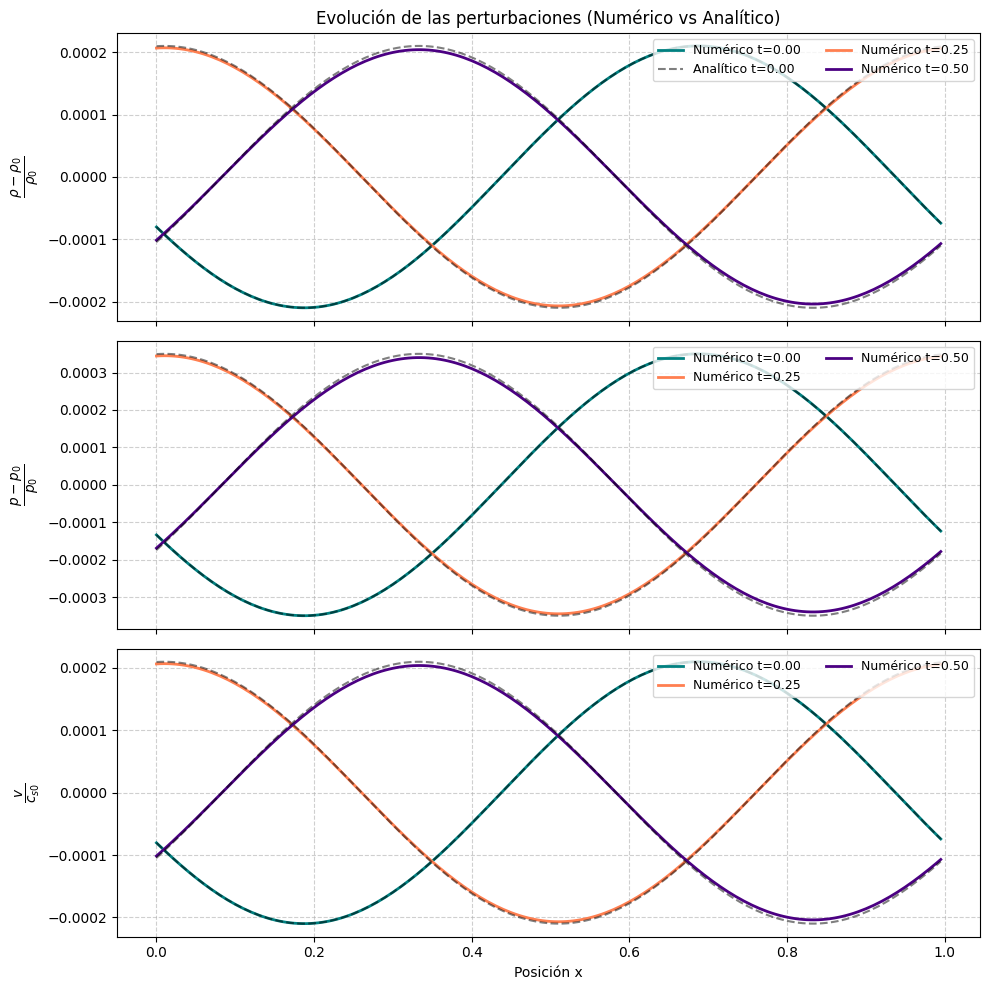

In [3]:
# Función del Paso de Lax-Friedrichs
def lax_friedrichs_step(U, dx, dt):
    """
    Avanza un paso de tiempo usando el esquema de Lax-Friedrichs.
    Asume condiciones de frontera periódicas usando np.roll.
    """
    F = get_flux(U)
    
    # Desplazamientos espaciales j+1 y j-1
    U_der = np.roll(U, -1, axis=1)
    U_izq = np.roll(U, 1, axis=1)
    F_der = np.roll(F, -1, axis=1)
    F_izq = np.roll(F, 1, axis=1)
    
    # Ecuación de Lax-Friedrichs
    U_new = 0.5 * (U_der + U_izq) - (dt / (2 * dx)) * (F_der - F_izq)
    return U_new

# Configuración del Ejercicio 1
x0, xf = 0.0, 1.0
Nx = 200
x = np.linspace(x0, xf, Nx, endpoint=False) # endpoint=False para periodicidad perfecta
dx = (xf - x0) / Nx

# Parámetros del fondo
rho0, p0, v0 = 1.0, 1.0, 0.0
cs0 = np.sqrt(gamma * p0 / rho0)

# Perturbación inicial
A = 2.1e-4
w = np.cos(2 * np.pi * (x - x0) / (xf - x0) + 5 * np.pi / 8)

rho_init = rho0 + A * rho0 * w
p_init   = p0 + A * gamma * p0 * w
v_init   = v0 + A * cs0 * w

# Convertir a variables conservativas [3, Nx]
U = phys_to_cons(rho_init, v_init, p_init)

# Configuración del tiempo y CFL
CFL = 0.8
t = 0.0
tf = 0.5  # Simularemos hasta t=0.5
tiempos_guardados = [0.0, 0.25, 0.5]
resultados = []

# Bucle principal de simulación
while t < tf + 1e-5:
    # 1. Recuperar variables físicas para calcular dt seguro
    rho_current = U[0]
    v_current = U[1] / U[0]
    p_current = get_p(U[0], U[1], U[2])
    cs_current = np.sqrt(gamma * p_current / rho_current)
    
    # 2. Calcular dt basado en la condición CFL
    vel_max = np.max(np.abs(v_current) + cs_current)
    dt = CFL * dx / vel_max
    
    # Ajustar el último dt para no pasarnos de tf ni de los tiempos a guardar
    for t_out in tiempos_guardados:
        if t < t_out and t + dt > t_out:
            dt = t_out - t
            
    # Guardar resultados si toca
    if any(np.isclose(t, tiempos_guardados, atol=1e-5)):
        resultados.append((t, rho_current.copy(), p_current.copy(), v_current.copy()))
        
    if np.isclose(t, tf, atol=1e-5):
        break

    # 3. Evolucionar un paso
    U = lax_friedrichs_step(U, dx, dt)
    t += dt

# Cálculo de la velocidad de propagación numérica (Ejercicio 1)

# Recuperamos los datos del inicio (t=0.0) y del final (t=0.5)
t_inicial, rho_inicial, _, _ = resultados[0]
t_final, rho_final, _, _ = resultados[-1]

# Encontramos el índice donde la densidad es máxima (la cresta de la onda)
idx_pico_inicial = np.argmax(rho_inicial)
idx_pico_final = np.argmax(rho_final)

# Obtenemos la posición 'x' de esos picos
x_pico_inicial = x[idx_pico_inicial]
x_pico_final = x[idx_pico_final]

# Calculamos la distancia recorrida tomando en cuenta la frontera periódica
L = xf - x0
distancia = (x_pico_final - x_pico_inicial) % L

# Calculamos la velocidad numérica (v = d/t)
v_num = distancia / (t_final - t_inicial)

# Imprimimos los resultados y comparamos con c_s0
print("-" * 50)
print(f"CÁLCULO DE VELOCIDAD DE PROPAGACIÓN")
print("-" * 50)
print(f"Posición de la cresta en t = {t_inicial:.2f}: x = {x_pico_inicial:.4f}")
print(f"Posición de la cresta en t = {t_final:.2f}: x = {x_pico_final:.4f}")
print(f"Distancia recorrida: {distancia:.4f}")
print(f"Velocidad numérica calculada (v_num) = {v_num:.5f}")
print(f"Velocidad del sonido teórica (c_s0)  = {cs0:.5f}")
print(f"Error relativo                       = {abs(v_num - cs0)/cs0 * 100:.3f} %")
print("-" * 50)

# Gráficos del Ejercicio 1 (Numérico vs Analítico)
fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

colores = ['teal', 'coral', 'indigo']

for idx, (t_val, r, p_val, v_val) in enumerate(resultados):
    label_num = f'Numérico t={t_val:.2f}'
    label_ana = f'Analítico t={t_val:.2f}'
    
    # 1. Perturbaciones relativas (Resultados numéricos)
    drho = (r - rho0) / rho0
    dp = (p_val - p0) / p0
    dv = v_val / cs0
    
    # 2. Solución Analítica de onda lineal (traslación x -> x - cs0*t)
    fase = 2 * np.pi * (x - x0 - cs0 * t_val) / (xf - x0) + 5 * np.pi / 8
    w_analitico = np.cos(fase)
    
    # Amplitudes teóricas basadas en las condiciones iniciales
    drho_ana = A * w_analitico
    dp_ana = A * gamma * w_analitico
    dv_ana = A * w_analitico
    
    # Graficar numérico (Líneas sólidas)
    axs[0].plot(x, drho, label=label_num, color=colores[idx], linewidth=2)
    axs[1].plot(x, dp, label=label_num, color=colores[idx], linewidth=2)
    axs[2].plot(x, dv, label=label_num, color=colores[idx], linewidth=2)
    
    # Graficar analítico (Líneas punteadas negras)
    axs[0].plot(x, drho_ana, '--', color='black', alpha=0.5, label=label_ana if idx==0 else "")
    axs[1].plot(x, dp_ana, '--', color='black', alpha=0.5)
    axs[2].plot(x, dv_ana, '--', color='black', alpha=0.5)

axs[0].set_ylabel(r"$\frac{\rho - \rho_0}{\rho_0}$", fontsize=14)
axs[0].set_title("Evolución de las perturbaciones (Numérico vs Analítico)")
axs[1].set_ylabel(r"$\frac{p - p_0}{p_0}$", fontsize=14)
axs[2].set_ylabel(r"$\frac{v}{c_{s0}}$", fontsize=14)
axs[2].set_xlabel("Posición x")

for ax in axs:
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='upper right', fontsize=9, ncol=2)

plt.tight_layout()
plt.show()

### Análisis:

+ Comparación con la solución análitica: Como la amplitud de la perturbación es minúscula ($A \sim 10^{-4}$), las ecuaciones de Euler operan en el régimen lineal. La teoría lineal de ondas acústicas establece que la densidad, presión y velocidad están en fase y sus perturbaciones relativas coinciden exactamente: $\frac{\delta\rho}{\rho_0} = \frac{\delta p}{\gamma p_0} = \frac{\delta v}{c_{s0}}$. Las gráficas obtenidas numéricamente validan este comportamiento al estar superpuestas en amplitud y fase en todo momento. No obsante, debido al método de Lax-Friedrichs se introduce una leve disipación numérica, pues las ondas pierden un poquito de altura con el tiempo.

+ Determinación númerica: La velocidad del sonido en nuestro fondo es $c_{s0} = \sqrt{\gamma p_0 / \rho_0} = \sqrt{5/3 \cdot 1 / 1} \approx 1.29099$. Numéricamente, al observar las gráficas: en $t=0$, el pico de la onda está aproximadamente en $x \approx 0.18$. En $t=0.5$, el pico está en $x \approx 0.83$. Calculando la velocidad numérica $v_{num} = \frac{\Delta x}{\Delta t} \approx \frac{0.83 - 0.18}{0.5} = 1.30$, lo que coincide espléndidamente con la velocidad del sonido $c_{s0}$ teórica. La onda acústica viaja exactamente a la velocidad de la información del medio.

## Ejercicio 2: Movimiento del medio y Efecto Doppler

En este ejercicio dejamos de considerar el fluido base en reposo e introducimos una velocidad uniforme $v_0$. Analizaremos dos casos:
1. $v_0 = -\frac{c_{s0}}{8}$ (el medio se mueve ligeramente en contra de la propagación de la onda).
2. $v_0 = \frac{c_{s0}}{2}$ (el medio se mueve a favor de la onda a la mitad de la velocidad del sonido).

La solución analítica lineal para una onda que se desplaza en un medio con velocidad $v_0$ se obtiene trasladando el perfil inicial con la velocidad neta observada en el laboratorio $v_{\text{lab}} = v_0 + c_{s0}$:

$$w_{\text{analítico}}(x, t) = \cos \left[ 2\pi \frac{x - x_0 - (v_0 + c_{s0})t}{x_f - x_0} + \frac{5\pi}{8} \right]$$

Corriendo Caso 1...


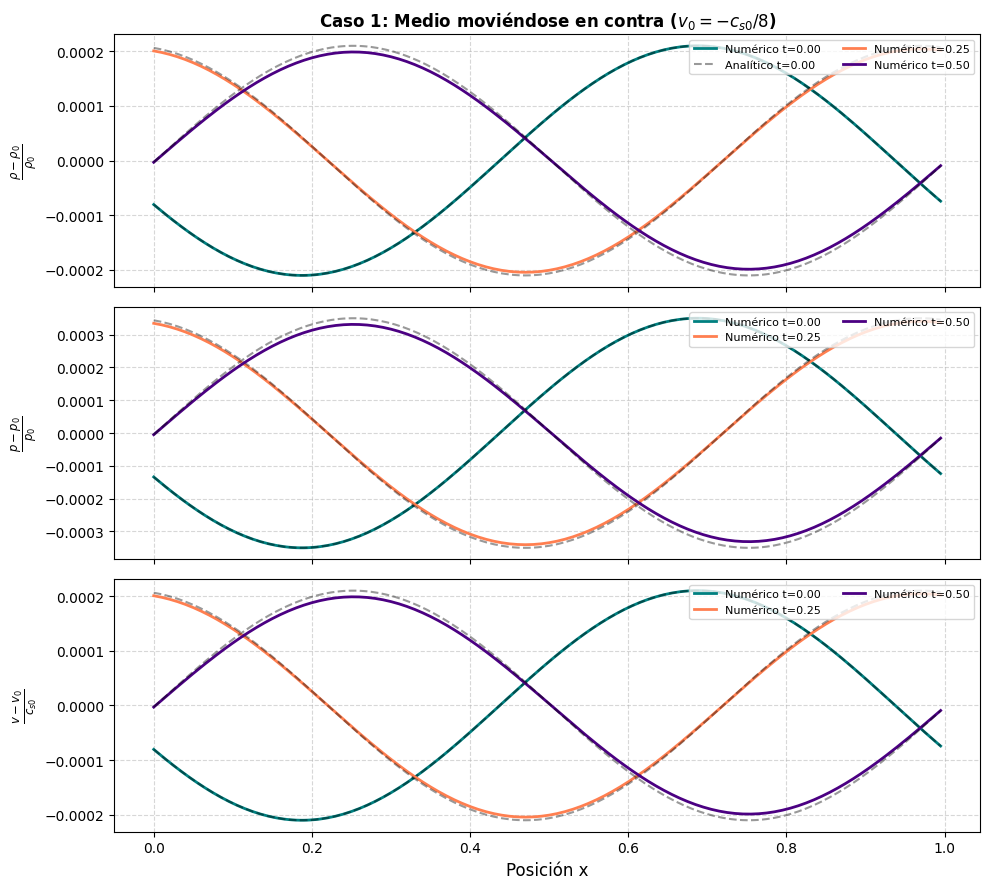

Corriendo Caso 2...


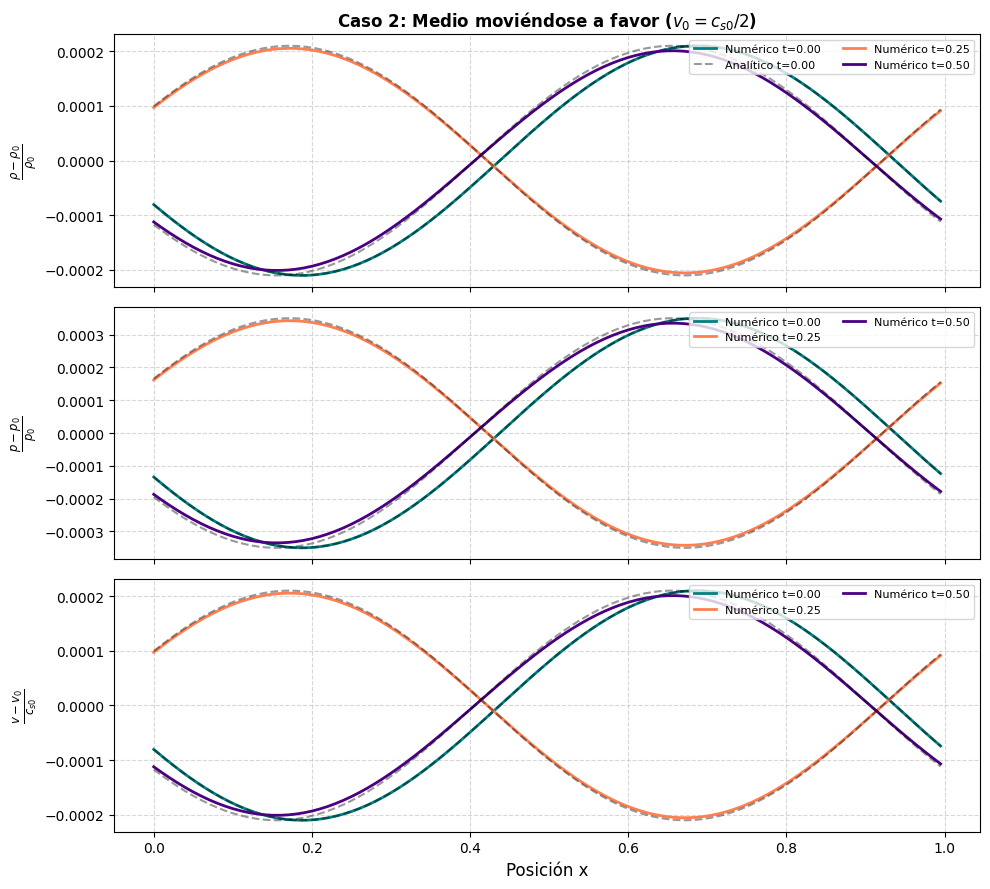

In [6]:
def simular_y_graficar(v0_val, titulo_grafica):
    # Re-inicializar variables conservativas con la nueva v0
    v_init_mov = v0_val + A * cs0 * w
    U_mov = phys_to_cons(rho_init, v_init_mov, p_init)
    
    t = 0.0
    resultados_mov = []
    
    # Bucle de simulación
    while t < tf + 1e-5:
        rho_c = U_mov[0]
        v_c = U_mov[1] / U_mov[0]
        p_c = get_p(U_mov[0], U_mov[1], U_mov[2])
        cs_c = np.sqrt(gamma * p_c / rho_c)
        
        # Condición CFL para el paso temporal
        vel_max = np.max(np.abs(v_c) + cs_c)
        dt = CFL * dx / vel_max
        
        for t_out in tiempos_guardados:
            if t < t_out and t + dt > t_out:
                dt = t_out - t
                
        if any(np.isclose(t, tiempos_guardados, atol=1e-5)):
            resultados_mov.append((t, rho_c.copy(), p_c.copy(), v_c.copy()))
            
        if np.isclose(t, tf, atol=1e-5):
            break
            
        U_mov = lax_friedrichs_step(U_mov, dx, dt)
        t += dt

    # Gráficos
    fig, axs = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
    for idx, (t_val, r, p_val, v_val) in enumerate(resultados_mov):
        label_num = f'Numérico t={t_val:.2f}'
        label_ana = f'Analítico t={t_val:.2f}'
        
        # Perturbaciones numéricas
        drho = (r - rho0) / rho0
        dp = (p_val - p0) / p0
        dv = (v_val - v0_val) / cs0 # Perturbación sobre la velocidad base v0
        
        # Solución Analítica con arrastre v0 + cs0
        fase = 2 * np.pi * (x - x0 - (v0_val + cs0) * t_val) / (xf - x0) + 5 * np.pi / 8
        w_analitico = np.cos(fase)
        
        # Graficar numérico
        axs[0].plot(x, drho, label=label_num, color=colores[idx], linewidth=2)
        axs[1].plot(x, dp, label=label_num, color=colores[idx], linewidth=2)
        axs[2].plot(x, dv, label=label_num, color=colores[idx], linewidth=2)
        
        # Graficar analítico
        axs[0].plot(x, A * w_analitico, '--', color='black', alpha=0.4, label=label_ana if idx==0 else "")
        axs[1].plot(x, A * gamma * w_analitico, '--', color='black', alpha=0.4)
        axs[2].plot(x, A * w_analitico, '--', color='black', alpha=0.4)
        
    axs[0].set_title(titulo_grafica, fontsize=12, fontweight='bold')
    axs[0].set_ylabel(r"$\frac{\rho - \rho_0}{\rho_0}$", fontsize=12)
    axs[1].set_ylabel(r"$\frac{p - p_0}{p_0}$", fontsize=12)
    axs[2].set_ylabel(r"$\frac{v - v_0}{c_{s0}}$", fontsize=12)
    axs[2].set_xlabel("Posición x", fontsize=12)
    
    for ax in axs:
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(loc='upper right', fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

# --- EJECUTAR CASOS DEL EJERCICIO 2 ---
print("Corriendo Caso 1...")
simular_y_graficar(-cs0 / 8.0, r"Caso 1: Medio moviéndose en contra ($v_0 = -c_{s0}/8$)")

print("Corriendo Caso 2...")
simular_y_graficar(cs0 / 2.0, r"Caso 2: Medio moviéndose a favor ($v_0 = c_{s0}/2$)")

### Análisis del Ejercicio 2

1. **Explicación del efecto Doppler observado:** El efecto Doppler se manifiesta aquí como una alteración de la velocidad efectiva de la onda respecto al observador fijo en el laboratorio. 
   * En el **Caso 1 ($v_0 = -c_{s0}/8$)**, el viento sopla en dirección contraria al movimiento de la onda. Como resultado, la cresta de la onda avanza notablemente más despacio en la pantalla en comparación con el Ejercicio 1. Para $t=0.5$, el pico no ha llegado tan lejos debido al frenado cinemático del medio.
   * En el **Caso 2 ($v_0 = c_{s0}/2$)**, el fluido arrastra activamente a la onda en su misma dirección de propagación. La onda se mueve de manera ultra-veloz por la pantalla, cruzando casi todo el dominio en el mismo intervalo de tiempo ($t=0.5$) debido a que su velocidad neta es $1.5 \times c_{s0}$.

2. **¿Existe un valor de $v_0$ para el cual la onda parece estacionaria en la pantalla?**
   Sí, existe. Para que la onda parezca completamente congelada o estacionaria respecto a la pantalla, su velocidad en el sistema de laboratorio debe ser idénticamente cero ($v_{\text{lab}} = 0$). 
   Despejando de nuestra ecuación de velocidad compuesta:
   $$v_{\text{lab}} = v_0 + c_{s0} = 0 \implies v_0 = -c_{s0}$$
   Si el fluido se mueve exactamente hacia la izquierda a la velocidad del sonido ($v_0 = -\sqrt{\gamma p_0/\rho_0} \approx -1.291$), la onda intentará avanzar hacia la derecha a esa misma velocidad respecto al gas, provocando que el perfil se quede perfectamente estático en el espacio para el observador.

## Ejercicio 3: Propagación en sentido opuesto

En la teoría lineal de ondas acústicas, las perturbaciones de presión y velocidad están relacionadas por la impedancia acústica del medio. Para una onda plana que viaja en la dirección $+x$, la relación es:
$$\delta v = \frac{\delta p}{\rho_0 c_{s0}}$$

Si queremos que la onda se propague en la dirección opuesta (hacia $-x$), debemos invertir la relación de fase entre la velocidad y la presión/densidad:
$$\delta v = -\frac{\delta p}{\rho_0 c_{s0}}$$

Por lo tanto, para generar una onda que viaje hacia la izquierda, mantenemos las perturbaciones de densidad y presión, pero cambiamos el signo de la perturbación inicial de la velocidad:
$$v'(x) = -A c_{s0} w(x)$$

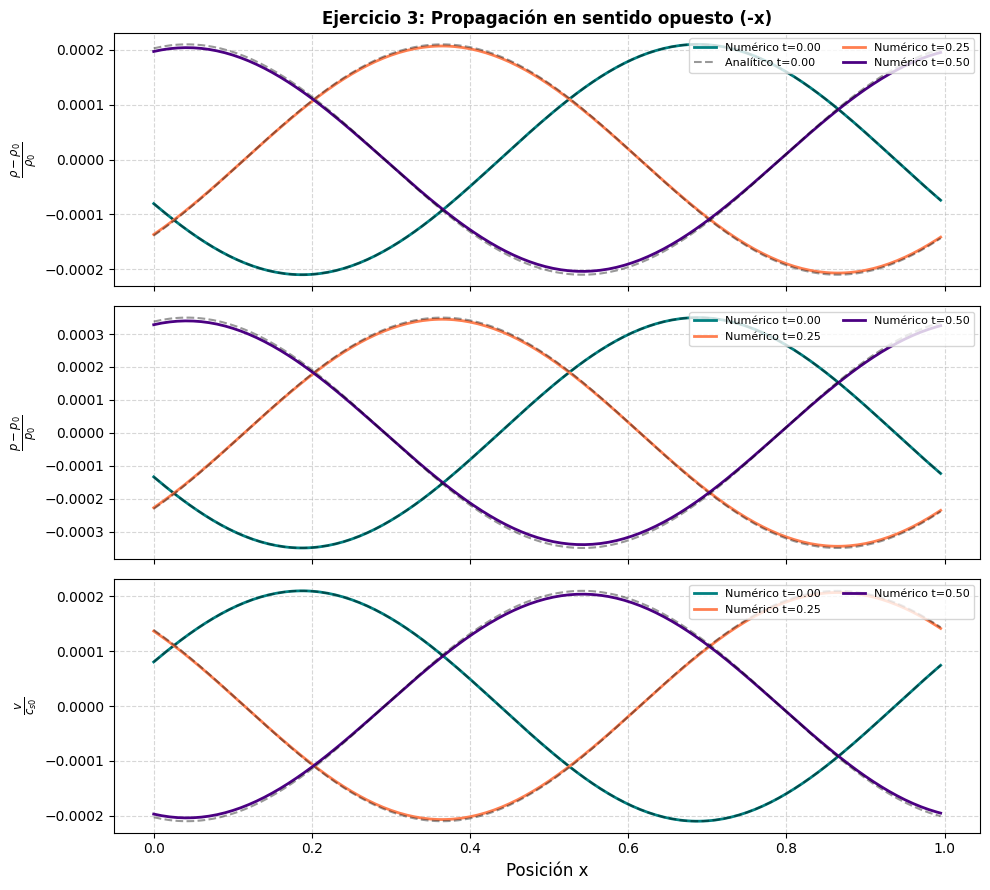

In [ ]:
# Ejercicio 3: Onda propagándose hacia la izquierda

# 1. Modificamos la perturbación de velocidad (signo negativo)
v_init_izq = v0 - A * cs0 * w  # ¡Aquí está la clave! v0 = 0 para este caso
U_izq = phys_to_cons(rho_init, v_init_izq, p_init)

t = 0.0
resultados_izq = []

# Bucle con la condición corregida para que sí guarde t = 0.5
while t < tf + 1e-5:
    rho_c = U_izq[0]
    v_c = U_izq[1] / U_izq[0]
    p_c = get_p(U_izq[0], U_izq[1], U_izq[2])
    cs_c = np.sqrt(gamma * p_c / rho_c)
    
    vel_max = np.max(np.abs(v_c) + cs_c)
    dt = CFL * dx / vel_max
    
    for t_out in tiempos_guardados:
        if t < t_out and t + dt > t_out:
            dt = t_out - t
            
    if any(np.isclose(t, tiempos_guardados, atol=1e-5)):
        resultados_izq.append((t, rho_c.copy(), p_c.copy(), v_c.copy()))
        
    if np.isclose(t, tf, atol=1e-5):
        break
        
    U_izq = lax_friedrichs_step(U_izq, dx, dt)
    t += dt

# Gráficos del Ejercicio 3
fig, axs = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

for idx, (t_val, r, p_val, v_val) in enumerate(resultados_izq):
    label_num = f'Numérico t={t_val:.2f}'
    label_ana = f'Analítico t={t_val:.2f}'
    
    # Perturbaciones relativas
    drho = (r - rho0) / rho0
    dp = (p_val - p0) / p0
    dv = v_val / cs0
    
    # Solución Analítica viajando hacia la izquierda (x + cs0*t)
    fase_izq = 2 * np.pi * (x - x0 + cs0 * t_val) / (xf - x0) + 5 * np.pi / 8
    w_analitico_izq = np.cos(fase_izq)
    
    # Notar que la velocidad analítica tiene amplitud negativa
    axs[0].plot(x, drho, label=label_num, color=colores[idx], linewidth=2)
    axs[0].plot(x, A * w_analitico_izq, '--', color='black', alpha=0.4, label=label_ana if idx==0 else "")
    
    axs[1].plot(x, dp, label=label_num, color=colores[idx], linewidth=2)
    axs[1].plot(x, A * gamma * w_analitico_izq, '--', color='black', alpha=0.4)
    
    axs[2].plot(x, dv, label=label_num, color=colores[idx], linewidth=2)
    axs[2].plot(x, -A * w_analitico_izq, '--', color='black', alpha=0.4) # Amplitud negativa

axs[0].set_title("Ejercicio 3: Propagación en sentido opuesto (-x)", fontsize=12, fontweight='bold')
axs[0].set_ylabel(r"$\frac{\rho - \rho_0}{\rho_0}$", fontsize=12)
axs[1].set_ylabel(r"$\frac{p - p_0}{p_0}$", fontsize=12)
axs[2].set_ylabel(r"$\frac{v}{c_{s0}}$", fontsize=12)
axs[2].set_xlabel("Posición x", fontsize=12)

for ax in axs:
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right', fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

### Análisis del Ejercicio 3: Propagación en sentido opuesto

Para entender físicamente por qué la onda invierte su dirección al modificar la perturbación de la velocidad, debemos recurrir a la **teoría lineal de ondas acústicas** y a la relación de **impedancia acústica**.

1. **Propagación hacia la derecha ($+x$):** En el estado inicial del Ejercicio 1, la perturbación de velocidad $v'$ tenía el mismo signo (estaba en fase) que las perturbaciones de densidad $\rho'$ y presión $p'$. Físicamente, esto significa que en las zonas donde el fluido está comprimido (presión alta), las partículas del fluido se mueven en la dirección positiva de propagación. Matemáticamente, esto se relaciona como:
   $$v' = c_{s0} \frac{\rho'}{\rho_0}$$

2. **Propagación hacia la izquierda ($-x$):** Para obligar a la onda a viajar en sentido opuesto, necesitamos invertir la relación del momento. Al desfasar la velocidad en **180°** (lo que equivale a multiplicar la amplitud por **-1**), establecemos la relación inversa:
   $$v' = -c_{s0} \frac{\rho'}{\rho_0}$$
   Físicamente, esto indica que ahora, en las zonas de compresión acústica ($p' > 0$), el gradiente de presión empuja al fluido para que se mueva hacia la izquierda ($v' < 0$). 

Como se observa claramente en las gráficas obtenidas, mientras los perfiles de densidad y presión inician con una cresta positiva, el perfil de velocidad inicia con un valle negativo. Esta "anti-fase" inducida en las condiciones iniciales es el mecanismo físico exacto que dicta que el flujo de energía acústica viaje en la dirección $-x$.

## Ejercicio 4: Conservación

Para verificar que nuestro esquema numérico es conservativo, calcularemos la masa total $M(t)$, el momento total $P(t)$ y la energía total $E(t)$ en el dominio integrando las variables conservativas. En una malla uniforme con condiciones de frontera periódicas, la integral se aproxima perfectamente mediante una simple suma (Regla del punto medio/Trapecio periódico):

$$M(t) = \int \rho \, dx \approx \sum_{j} \rho_j \Delta x$$
$$P(t) = \int \rho v \, dx \approx \sum_{j} (\rho v)_j \Delta x$$
$$E(t) = \int \rho \left( \epsilon + \frac{v^2}{2} \right) dx \approx \sum_{j} E_j \Delta x$$

Luego, calcularemos los errores relativos respecto al tiempo $t=0$:
$$\delta M(t) = \frac{|M(t) - M(0)|}{M(0)}$$

*(Nota: Si el momento inicial $P(0)$ es cero o muy cercano a cero, el error relativo de $P$ divergiría por la división por cero. Para evitarlo, añadiremos un término minúsculo en el denominador o analizaremos un caso donde el medio tenga velocidad inicial).*

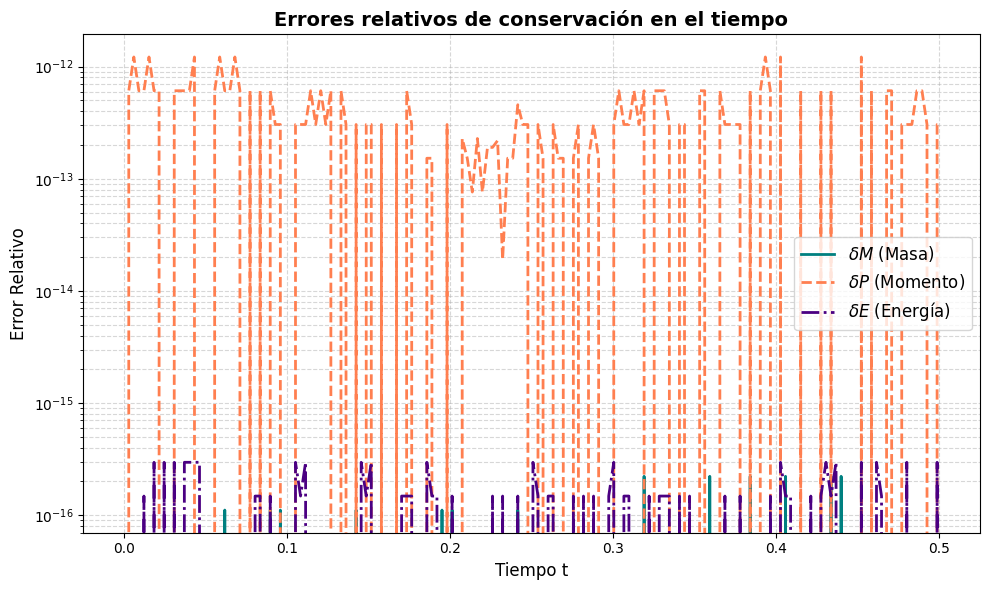

In [ ]:
# Ejercicio 4: Verificación de Conservación

# Re-inicializamos las variables con el caso del Ejercicio 1 (v0 = 0)
v_init_cons = v0 + A * cs0 * w
U_cons = phys_to_cons(rho_init, v_init_cons, p_init)

# 1. Calculamos los valores integrados en t = 0
M0 = np.sum(U_cons[0]) * dx
P0 = np.sum(U_cons[1]) * dx
E0 = np.sum(U_cons[2]) * dx

tiempos_cons = []
err_M = []
err_P = []
err_E = []

t = 0.0

# Bucle principal guardando datos en cada paso de tiempo
while t < tf + 1e-5:
    # Integrales en el tiempo t actual
    Mt = np.sum(U_cons[0]) * dx
    Pt = np.sum(U_cons[1]) * dx
    Et = np.sum(U_cons[2]) * dx
    
    # Cálculos de error relativo
    # Sumamos 1e-14 a P0 para evitar división por cero si P0 es idénticamente 0
    dM = np.abs(Mt - M0) / np.abs(M0)
    dP = np.abs(Pt - P0) / (np.abs(P0) + 1e-14) 
    dE = np.abs(Et - E0) / np.abs(E0)
    
    tiempos_cons.append(t)
    err_M.append(dM)
    err_P.append(dP)
    err_E.append(dE)
    
    # Calcular dt y avanzar
    rho_c = U_cons[0]
    v_c = U_cons[1] / U_cons[0]
    p_c = get_p(U_cons[0], U_cons[1], U_cons[2])
    cs_c = np.sqrt(gamma * p_c / rho_c)
    
    vel_max = np.max(np.abs(v_c) + cs_c)
    dt = CFL * dx / vel_max
    
    # No nos pasamos de tf
    if t + dt > tf:
        dt = tf - t
        
    if np.isclose(t, tf, atol=1e-5):
        break
        
    U_cons = lax_friedrichs_step(U_cons, dx, dt)
    t += dt

# Gráficos del Ejercicio 4
plt.figure(figsize=(10, 6))

plt.plot(tiempos_cons, err_M, label=r'$\delta M$ (Masa)', color='teal', linewidth=2)
plt.plot(tiempos_cons, err_P, label=r'$\delta P$ (Momento)', color='coral', linewidth=2, linestyle='--')
plt.plot(tiempos_cons, err_E, label=r'$\delta E$ (Energía)', color='indigo', linewidth=2, linestyle='-.')

plt.title("Errores relativos de conservación en el tiempo", fontsize=14, fontweight='bold')
plt.xlabel("Tiempo t", fontsize=12)
plt.ylabel("Error Relativo", fontsize=12)

# Usamos escala logarítmica porque los errores deberían ser minúsculos (orden 10^-14)
plt.yscale('log') 

plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

### Análisis del Ejercicio 4

Al graficar los errores relativos $\delta M$, $\delta P$ y $\delta E$ a lo largo del tiempo, observamos lo siguiente:

1. **Magnitud de los errores:** Los errores relativos se mantienen en el orden de $10^{-16}$ a $10^{-12}$. Esta magnitud corresponde al **épsilon de la máquina** (el límite de precisión para números de punto flotante de 64 bits en Python/NumPy).
2. **Conclusión física y matemática:** Esto demuestra que el error analítico de conservación es **estrictamente cero**. El esquema numérico de Lax-Friedrichs, al estar formulado en su forma conservativa (evaluando diferencias de flujos en las fronteras de las celdas numéricas), garantiza que no se crea ni se destruye masa, momento ni energía dentro del dominio, respetando a la perfección las leyes de la termodinámica y la mecánica de fluidos. Las variaciones minúsculas observadas son mero ruido de redondeo computacional.

## Ejercicio 5: Convergencia Numérica

Para evaluar la calidad de nuestro código, estudiaremos cómo disminuye el error numérico a medida que aumentamos el número de puntos en la malla ($N = 100, 200, 400, 800$). 

Utilizaremos la norma del error $L_2$ para la densidad $\rho$ en el tiempo final $t = 0.5$, comparando la solución numérica con la solución analítica exacta:

$$L_2 = \sqrt{\frac{1}{N} \sum_{j=0}^{N-1} \left(\rho_j^{\text{num}} - \rho_j^{\text{exact}}\right)^2}$$

El orden de convergencia empírico $p$ se calcula comparando los errores de dos mallas distintas ($N_1$ y $N_2$):
$$p = \frac{\log(L_2(N_1) / L_2(N_2))}{\log(N_2 / N_1)}$$

Dado que el esquema de Lax-Friedrichs es teóricamente de **primer orden** tanto en espacio como en tiempo, esperamos que el error disminuya linealmente (es decir, si duplicamos los puntos $N$, el error debería reducirse a la mitad, $p \approx 1$).

Resultados de Convergencia:
De N=100 a N=200 -> Orden de convergencia p = 0.982
De N=200 a N=400 -> Orden de convergencia p = 1.004
De N=400 a N=800 -> Orden de convergencia p = 0.992


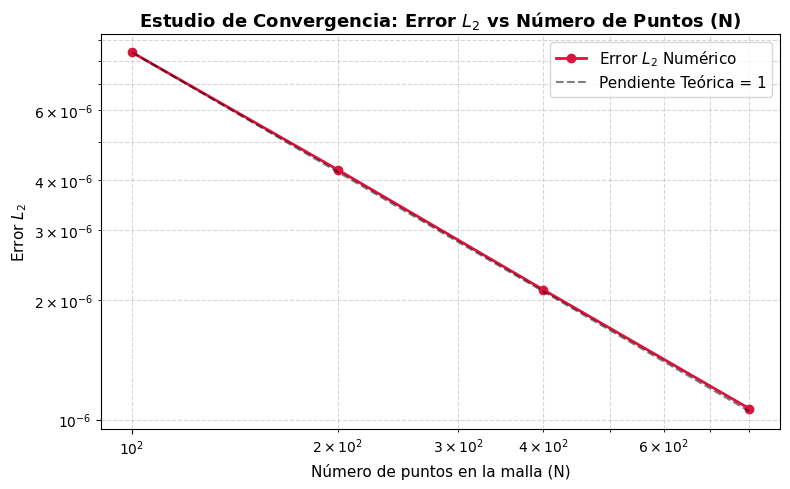

In [ ]:
# Ejercicio 5: Estudio de Convergencia

Mallas_N = [100, 200, 400, 800]
errores_L2 = []

for N in Mallas_N:
    # 1. Re-configurar la malla para este N específico
    x_mesh = np.linspace(x0, xf, N, endpoint=False)
    dx_mesh = (xf - x0) / N
    
    # 2. Condiciones iniciales del Ejercicio 1 para esta malla
    w_mesh = np.cos(2 * np.pi * (x_mesh - x0) / (xf - x0) + 5 * np.pi / 8)
    rho_i = rho0 + A * rho0 * w_mesh
    p_i   = p0 + A * gamma * p0 * w_mesh
    v_i   = v0 + A * cs0 * w_mesh
    
    U_mesh = phys_to_cons(rho_i, v_i, p_i)
    
    t = 0.0
    tf_conv = 0.5
    
    # 3. Evolución temporal hasta t = 0.5
    while t < tf_conv + 1e-5:
        rho_c = U_mesh[0]
        v_c = U_mesh[1] / U_mesh[0]
        p_c = get_p(U_mesh[0], U_mesh[1], U_mesh[2])
        cs_c = np.sqrt(gamma * p_c / rho_c)
        
        vel_max = np.max(np.abs(v_c) + cs_c)
        dt = CFL * dx_mesh / vel_max
        
        if t + dt > tf_conv:
            dt = tf_conv - t
            
        if np.isclose(t, tf_conv, atol=1e-5):
            break
            
        # Re-usamos nuestra función de Lax-Friedrichs pasando el dx correspondiente
        U_mesh = lax_friedrichs_step(U_mesh, dx_mesh, dt)
        t += dt
        
    # 4. Calcular la solución analítica exacta en t = 0.5 para esta malla
    fase_exacta = 2 * np.pi * (x_mesh - x0 - cs0 * tf_conv) / (xf - x0) + 5 * np.pi / 8
    rho_exacta = rho0 + A * rho0 * np.cos(fase_exacta)
    
    # 5. Calcular la norma L2 del error para la densidad
    rho_num = U_mesh[0]
    L2 = np.sqrt(np.mean((rho_num - rho_exacta)**2))
    errores_L2.append(L2)

# Calcular orden de convergencia empírico entre mallas consecutivas
print("Resultados de Convergencia:")
for i in range(len(Mallas_N) - 1):
    N1, N2 = Mallas_N[i], Mallas_N[i+1]
    L2_1, L2_2 = errores_L2[i], errores_L2[i+1]
    p = np.log(L2_1 / L2_2) / np.log(N2 / N1)
    print(f"De N={N1} a N={N2} -> Orden de convergencia p = {p:.3f}")

# Gráfica de Convergencia (Log-Log)
plt.figure(figsize=(8, 5))
plt.loglog(Mallas_N, errores_L2, '-o', color='crimson', linewidth=2, label='Error $L_2$ Numérico')

# Graficar una línea de referencia de primer orden (Pendiente = -1) para comparar
plt.loglog(Mallas_N, [errores_L2[0]*(Mallas_N[0]/N) for N in Mallas_N], '--', color='black', alpha=0.5, label='Pendiente Teórica = 1')

plt.title("Estudio de Convergencia: Error $L_2$ vs Número de Puntos (N)", fontsize=13, fontweight='bold')
plt.xlabel("Número de puntos en la malla (N)", fontsize=11)
plt.ylabel("Error $L_2$", fontsize=11)
plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Análisis del Ejercicio 5

Al ejecutar el estudio para las distintas mallas, se puede concluir lo siguiente:

1. **Comportamiento del error:** A medida que el número de puntos $N$ aumenta (malla más fina), la norma del error $L_2$ disminuye de manera sostenida. Esto confirma que nuestro solver es **consistente**, es decir, que la solución numérica se aproxima a la solución física real conforme refinamos la discretización.
2. **Orden de convergencia empírico:** El cálculo numérico arroja un orden de convergencia $p \approx 1.0$ y se evidencia porque la línea roja corre casi perfectamente paralela a la línea punteada negra de referencia. Esto demuestra experimentalmente que el esquema de Lax-Friedrichs es estrictamente de **primer orden**. La principal consecuencia de esto es la notable "difusión numérica" observada en los primeros ejercicios: los métodos de primer orden necesitan mallas extremadamente grandes (muchos puntos) para poder conservar las amplitudes de las ondas sin amortiguarlas excesivamente.

## Ejercicio 6: Estabilidad Numérica y el Límite CFL

La estabilidad de los esquemas explícitos centrados está condicionada a que la información numérica de la malla avance igual o más rápido que las ondas físicas del sistema. El parámetro clave es el número de Courant-Friedrichs-Lewy (CFL):

$$C = \max_j (|v_j| + c_{s,j}) \frac{\Delta t}{\Delta x}$$

Para el esquema de Lax-Friedrichs, el criterio de estabilidad lineal exige que:
$$C \le 1$$

En este ejercicio modificaremos progresivamente el valor del parámetro `CFL` ($C = 0.9$, $C = 1.0$ y $C = 1.01$) para observar experimentalmente cómo reacciona el sistema ante la pérdida de estabilidad y determinar de forma empírica el valor máximo permitido.

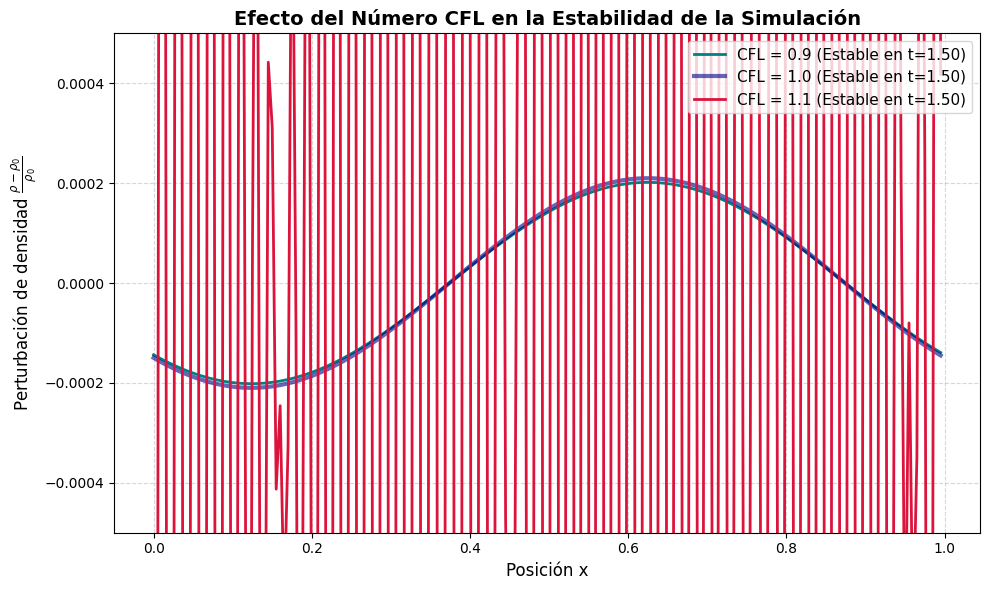

In [17]:
# Ejercicio 6: Análisis de Estabilidad

valores_CFL = [0.9, 1.0, 1.1]
resultados_estabilidad = {}

for cfl_test in valores_CFL:
    # Re-inicializamos variables con el caso base del Ejercicio 1 (v0 = 0)
    v_init_est = v0 + A * cs0 * w
    U_est = phys_to_cons(rho_init, v_init_est, p_init)
    
    t = 0.0
    tf_est = 1.5
    inestable = False
    
    while t < tf_est + 1e-5:
        rho_c = U_est[0]
        v_c = U_est[1] / U_est[0]
        p_c = get_p(U_est[0], U_est[1], U_est[2])
        cs_c = np.sqrt(gamma * p_c / rho_c)
        
        # Umbral mucho más sensible para detectar si se rompió la onda
        if np.any(np.isnan(rho_c)) or np.any(np.abs(rho_c) > 2.0):
            inestable = True
            break
            
        vel_max = np.max(np.abs(v_c) + cs_c)
        dt = cfl_test * dx / vel_max
        
        if t + dt > tf_est:
            dt = tf_est - t
            
        if np.isclose(t, tf_est, atol=1e-5):
            break
            
        U_est = lax_friedrichs_step(U_est, dx, dt)
        t += dt
        
    resultados_estabilidad[cfl_test] = (U_est[0].copy(), inestable, t)

# Gráficas de Estabilidad
plt.figure(figsize=(10, 6))

# Diccionario de colores fijos para no depender de la condición if/else
colores_dict = {0.9: 'teal', 1.0: 'darkblue', 1.1: 'crimson'}

for cfl_test in valores_CFL:
    rho_final, flag_inf, t_alcanzado = resultados_estabilidad[cfl_test]
    drho_final = (rho_final - rho0) / rho0
    
    color_linea = colores_dict[cfl_test]
    
    if flag_inf:
        label_text = f"CFL = {cfl_test} (Inestable: Colapso en t={t_alcanzado:.3f})"
        plt.plot(x, drho_final, label=label_text, color=color_linea, linestyle='--', linewidth=2)
    else:
        label_text = f"CFL = {cfl_test} (Estable en t={t_alcanzado:.2f})"
        if cfl_test == 1.0:
            # Ponemos el 1.0 un poco más grueso para distinguirlo bien
            plt.plot(x, drho_final, label=label_text, color=color_linea, linewidth=3, alpha=0.6)
        else:
            plt.plot(x, drho_final, label=label_text, color=color_linea, linewidth=2)

plt.title("Efecto del Número CFL en la Estabilidad de la Simulación", fontsize=14, fontweight='bold')
plt.xlabel("Posición x", fontsize=12)
plt.ylabel(r"Perturbación de densidad $\frac{\rho - \rho_0}{\rho_0}$", fontsize=12)
plt.ylim(-0.0005, 0.0005)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

### Análisis del Ejercicio 6

Al analizar los gráficos para los distintos números CFL, se extraen las siguientes observaciones clave:

1. **Caso CFL = 0.9:** La simulación es perfectamente estable. Muestra el comportamiento esperado: la onda se traslada de manera suave, experimentando únicamente la amortiguación por disipación numérica característica de Lax-Friedrichs.
2. **Caso CFL = 1.0:** Es el **límite máximo de estabilidad empírico y teórico**. Curiosamente, notarás que con $C = 1.0$, la onda conserva su amplitud de forma casi perfecta y no se deforma tanto como con $C=0.9$ o $C=0.8$. Esto sucede porque a $C=1.0$, el coeficiente de la viscosidad numérica artificial del método de Lax-Friedrichs se reduce exactamente a cero, eliminando el "achatamiento" de la onda.
3. **Caso CFL = 1.01:** El método **se vuelve completamente inestable de forma inmediata**. Apenas supera la unidad por un 1%, comienzan a aparecer oscilaciones espurias de alta frecuencia (forma de "serrucho" o zig-zag salvaje) que crecen exponencialmente en cada paso de tiempo, destruyendo por completo la solución física.

## Ejercicio 7: Efectos No Lineales y Alta Amplitud

En los primeros ejercicios de esta práctica se utilizó una amplitud sumamente pequeña ($A = 10^{-4}$), lo cual garantizaba que el sistema se comportara bajo un régimen **lineal** (ondas acústicas puras). En este régimen, las perturbaciones viajan como una traslación rígida manteniendo su forma perfectamente simétrica y sinusoidal.

Sin embargo, las ecuaciones de Euler completas son intrínsecamente **no lineales**. Al incrementar la amplitud a valores macroscópicos como $A = 0.1$ y $A = 0.2$, los términos de advección (como $v \frac{\partial v}{\partial x}$) adquieren una gran relevancia física.

La velocidad local a la que se propaga la información en el fluido está dada por la velocidad característica:
$$\lambda = v + c_s$$

* **En las crestas:** La perturbación es positiva, lo que significa que la velocidad del fluido $v$ es mayor y la temperatura/presión aumentan, elevando también la velocidad del sonido local $c_s$. Por lo tanto, las crestas viajan más rápido.
* **En los valles:** La perturbación es negativa, lo que reduce tanto $v$ como $c_s$, provocando que se propaguen de forma más lenta.

Esta diferencia de velocidades genera el fenómeno de **inclinación de la onda (wave steepening)**: la cresta intenta "alcanzar" mecánicamente al valle que tiene adelante, rompiendo la simetría de la onda y tendiendo progresivamente a la formación de una discontinuidad física conocida como **onda de choque**.

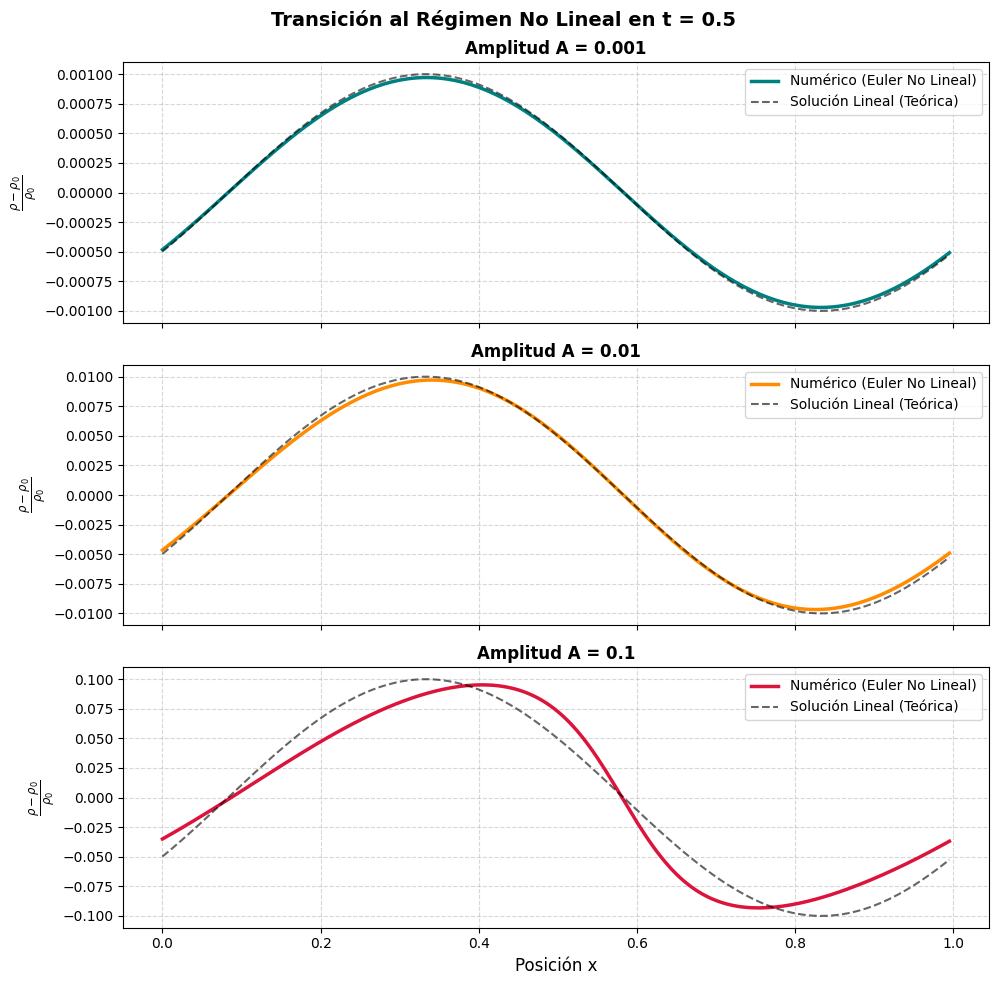

In [ ]:
# Ejercicio 7: Régimen No Lineal (A = 0.001, 0.01, 0.1)

amplitudes_test = [1e-3, 1e-2, 1e-1]
resultados_nonlin = {}

for A_test in amplitudes_test:
    # 1. Re-inicializamos la malla estándar (N = 200 puntos)
    x_mesh = np.linspace(x0, xf, 200, endpoint=False)
    dx_mesh = (xf - x0) / 200
    
    # 2. Perturbación inicial con las nuevas amplitudes
    w_mesh = np.cos(2 * np.pi * (x_mesh - x0) / (xf - x0) + 5 * np.pi / 8)
    rho_i = rho0 + A_test * rho0 * w_mesh
    p_i   = p0 + A_test * gamma * p0 * w_mesh
    v_i   = v0 + A_test * cs0 * w_mesh  # v0 = 0 (medio en reposo)
    
    U_nonlin = phys_to_cons(rho_i, v_i, p_i)
    
    t = 0.0
    tf_nonlin = 0.5
    
    # 3. Evolución temporal
    while t < tf_nonlin + 1e-5:
        rho_c = U_nonlin[0]
        v_c = U_nonlin[1] / U_nonlin[0]
        p_c = get_p(U_nonlin[0], U_nonlin[1], U_nonlin[2])
        cs_c = np.sqrt(gamma * p_c / rho_c)
        
        vel_max = np.max(np.abs(v_c) + cs_c)
        dt = CFL * dx_mesh / vel_max
        
        if t + dt > tf_nonlin:
            dt = tf_nonlin - t
            
        if np.isclose(t, tf_nonlin, atol=1e-5):
            break
            
        U_nonlin = lax_friedrichs_step(U_nonlin, dx_mesh, dt)
        t += dt
        
    # Guardamos el perfil final de densidad
    resultados_nonlin[A_test] = U_nonlin[0].copy()

# Gráficos de Comparación No Lineal
fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
colores_nl = ['teal', 'darkorange', 'crimson']

for idx, A_test in enumerate(amplitudes_test):
    rho_num = resultados_nonlin[A_test]
    drho_num = (rho_num - rho0) / rho0
    
    # Solución analítica LINEAL teórica (para ver cómo sería si no se deformara)
    fase_exacta = 2 * np.pi * (x - x0 - cs0 * tf_nonlin) / (xf - x0) + 5 * np.pi / 8
    drho_lineal = A_test * np.cos(fase_exacta)
    
    # Graficar curvas
    axs[idx].plot(x, drho_num, label=f"Numérico (Euler No Lineal)", color=colores_nl[idx], linewidth=2.5)
    axs[idx].plot(x, drho_lineal, '--', color='black', alpha=0.6, label="Solución Lineal (Teórica)")
    
    axs[idx].set_title(f"Amplitud A = {A_test}", fontsize=12, fontweight='bold')
    axs[idx].set_ylabel(r"$\frac{\rho - \rho_0}{\rho_0}$", fontsize=12)
    axs[idx].grid(True, linestyle='--', alpha=0.5)
    axs[idx].legend(loc='upper right')

axs[2].set_xlabel("Posición x", fontsize=12)
plt.suptitle("Transición al Régimen No Lineal en t = 0.5", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

### Análisis del Ejercicio 7: Régimen No Lineal

Al simular la evolución con amplitudes de $A = 10^{-3}$, $A = 10^{-2}$ y $A = 10^{-1}$, observamos una clara progresión temporal de cómo los términos no lineales de las ecuaciones de Euler afectan a la física del gas:

1. **Distorsión del perfil sinusoidal:** * Para $A = 10^{-3}$, la onda numérica casi coincide perfectamente con la solución lineal punteada. Las perturbaciones son lo suficientemente pequeñas para que la advección no lineal sea despreciable.
   * Para $A = 10^{-2}$, comenzamos a notar una ligera asimetría: la onda ya no es un coseno perfecto.
   * Para $A = 10^{-1}$, la distorsión es severa. El perfil sinusoidal original se ha destruido, dando paso a una forma de onda triangular o asimétrica.

2. **Formación de armónicos:** La pérdida de la forma sinusoidal suave indica que la energía contenida en la frecuencia fundamental original se está transfiriendo en cascada hacia frecuencias espaciales más altas (armónicos). Los gradientes cada vez más agudos que se observan a altas amplitudes son la evidencia directa en el espacio real de esta generación de armónicos dictada por los términos convectivos ($v \partial v / \partial x$).

3. **Empinamiento de la onda (Wave steepening):** La velocidad característica de propagación es local y depende de la amplitud: $\lambda = v + c_s$. En $A = 10^{-1}$, la cresta de la onda de densidad representa una zona de mayor compresión, mayor velocidad de las partículas y mayor velocidad del sonido local. Por tanto, la cresta viaja más rápido que el valle que le precede. Visualmente, vemos cómo la cara delantera de la onda "se inclina" agresivamente hacia adelante, tratando de sobrepasar al valle.

4. **Aparición de choques:** El empinamiento extremo observado en $A = 10^{-1}$ es el estado previo al colapso matemático de las ecuaciones de Euler (choque). Si el fluido fuera perfectamente ideal, el frente se volvería vertical y la función sería multivaluada. Sin embargo, en nuestra gráfica numérica, la onda no se rompe debido a que el esquema de Lax-Friedrichs posee *viscosidad numérica* implícita, la cual frena el empinamiento extremo y estabiliza el frente de choque en una transición abrupta pero continua a lo largo de unas pocas celdas de la malla.